In [55]:
import numpy as np
import pandas as pd
from fractions import Fraction
from math import floor, gcd, log, log2
import matplotlib.pyplot as plt
import json
import os
import time
import glob

from qiskit import transpile

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.transpiler import CouplingMap, generate_preset_pass_manager
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeKingston, FakeBoston, FakeTorino, FakePittsburgh, FakeMiami

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.noise import ReadoutError

from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
# code from https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm

def a2kmodN (a, k , N):

    for _ in range (k):
        a = int (np.mod (a**2, N))
    return a

In [3]:
# code from https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm

'''
def modMultGate (b, N):

    if gcd (b, N) > 1:
        print (f"Error: gcd ({b}, {N}) > 1")
    else:
        n = floor (log (N - 1, 2)) + 1
        U = np.full ((2**n , 2**n), 0)
        for x in range (N):
            U[b * x % N][x] = 1
        for x in range (N, 2**n):
            U[x][x] = 1
        G = UnitaryGate (U)
        G.name = f"M_{b}"

        return G
'''

'\n# code from https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm\n\ndef modMultGate (b, N):\n\n    if gcd (b, N) > 1:\n        print (f"Error: gcd ({b}, {N}) > 1")\n    else:\n        n = floor (log (N - 1, 2)) + 1\n        U = np.full ((2**n , 2**n), 0)\n        for x in range (N):\n            U[b * x % N][x] = 1\n        for x in range (N, 2**n):\n            U[x][x] = 1\n        G = UnitaryGate (U)\n        G.name = f"M_{b}"\n\n        return G\n'

In [3]:
#rotationGate method based off the description from Yang/Markidis paper, optimized by AI from an original bubble-swap version to a single cycle-decomposition

def rotationGate (numQubits, shift):

    qc = QuantumCircuit (numQubits)

    shift = shift % numQubits

    if shift != 0:
        visited = [False] * numQubits
        for start in range (numQubits):
            if visited[start]:
                continue
            
            cycle = [start]
            visited[start] = True
            nxt = (start + shift) % numQubits
            
            while nxt != start:
                cycle.append (nxt)
                visited[nxt] = True
                nxt = (nxt + shift) % numQubits

            for i in range (len (cycle) - 1):
                qc.swap (cycle[i], cycle[i + 1])

    G = qc.to_gate()
    G.name = f"Rot{shift}"

    return G

In [73]:
# code from https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm

'''
N = 31
a = 2
numTarget = floor (log (N - 1, 2)) + 1
numControl = 8

bList = [a2kmodN (a, k, N) for k in range (numControl)]

control = QuantumRegister (numControl, name = "C")
target = QuantumRegister (numTarget, name = "T")
output = ClassicalRegister (numControl, name = "out")
circuit = QuantumCircuit (control, target, output)

circuit.x (target[0])

for qubit, b in zip (control, bList):
    circuit.h (qubit)
    circuit.compose (modMultGate (b, N).control(), qubits = [qubit] + list (target), inplace = True)
        
circuit.compose (QFT (numControl, inverse = True), qubits = control, inplace = True)

circuit.measure (control, output)
'''

'\n# code from https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm\n\nN = 31\na = 2\nnumTarget = floor (log (N - 1, 2)) + 1\nnumControl = 8\n\nbList = [a2kmodN (a, k, N) for k in range (numControl)]\n\ncontrol = QuantumRegister (numControl, name = "C")\ntarget = QuantumRegister (numTarget, name = "T")\noutput = ClassicalRegister (numControl, name = "out")\ncircuit = QuantumCircuit (control, target, output)\n\ncircuit.x (target[0])\n\nfor qubit, b in zip (control, bList):\n    circuit.h (qubit)\n    circuit.compose (modMultGate (b, N).control(), qubits = [qubit] + list (target), inplace = True)\n\ncircuit.compose (QFT (numControl, inverse = True), qubits = control, inplace = True)\n\ncircuit.measure (control, output)\n'

In [102]:
# code modified from https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm

def makeCircuit (N, a, t, approxDegree = 0):

    numTarget = floor (log (N - 1, 2)) + 1
    
    bList = [a2kmodN (a, k, N) for k in range (t)]
    
    control = QuantumRegister (t, name = "C")
    target = QuantumRegister (numTarget, name = "T")
    output = ClassicalRegister (t, name = "out")
    circuit = QuantumCircuit (control, target, output)
    
    circuit.x (target[0])
    
    for qubit, b in zip (control, bList):
        circuit.h (qubit)
        assert b > 0 and (b & (b - 1)) == 0
        shift = int (log2 (b))
        circuit.compose (rotationGate (numTarget, shift).control(), qubits = [qubit] + list (target), inplace = True)
            
    circuit.compose (QFT (t, inverse = True, approximation_degree = approxDegree), qubits = control, inplace = True)
    
    circuit.measure (control, output)

    return circuit

In [76]:
# code from https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm

'''
couplingMap = CouplingMap.from_line (14)
pm = generate_preset_pass_manager (coupling_map = couplingMap)
transpiledCirc = pm.run (circuit)
deep = transpiledCirc
for _ in range (10):
    deep = deep.decompose()

print (f"2q-depth:  {deep.depth (lambda x: x.operation.num_qubits == 2)}")
print (f"2q-size:  {deep.size (lambda x: x.operation.num_qubits == 2)}")
print (f"Operator counts:  {deep.count_ops()}")
#deep.decompose().draw (output = "mpl", fold = -1, style = "clifford", idle_wires = False)
'''

2q-depth:  1409
2q-size:  1958
Operator counts:  OrderedDict({'u': 2936, 'cx': 1958, 'measure': 8})


In [170]:
# code from https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm
# seed candidate optimization from AI, used to cut down time from running on backend due to time constraints

def runExperiment (backend, circuit, shots = 1024):

    start = time.perf_counter()
    best = None
    for seed in range (8):
        candidate = transpile (circuit, backend, optimization_level = 1, seed_transpiler = seed)
        n2q = candidate.count_ops().get('cz', 0) + candidate.count_ops().get('cx', 0)
        if best is None or n2q < best[0]:
            best = (n2q, candidate)
    compiled = best[1]
    #compiled = transpile (circuit, backend, optimization_level = 1)
    #print (compiled.count_ops())
    #print ("Transpile:", time.perf_counter() - start)

    start = time.perf_counter()
    job = backend.run (compiled, shots = shots)
    #print ("Submitted:", time.perf_counter() - start)

    start = time.perf_counter()
    results = job.result()
    counts = results.get_counts()
    #print (results.results[0].metadata.get ('method'))
    #print ("Result:", time.perf_counter() - start)

    return counts

In [7]:
# noise code from https://deepwiki.com/Qiskit/qiskit-aer/7-noise-simulation

def createNoiseModel (error1, error2, readoutError):

    error1 = depolarizing_error (error1, 1)
    error2 = depolarizing_error (error2, 2)
    
    readoutError = ReadoutError ([[1 - readoutError, readoutError], [readoutError, 1 - readoutError]])

    noiseList = [("Ideal", None)]

    noiseModel1 = NoiseModel()
    noiseModel1.add_all_qubit_quantum_error (error1, ["h", "x"])
    noiseList.append (("1Q", noiseModel1))
    
    noiseModel2 = NoiseModel()
    noiseModel2.add_all_qubit_quantum_error (error2, ["cx"])
    noiseList.append (("2Q", noiseModel2))
    
    noiseModel3 = NoiseModel()
    noiseModel3.add_all_qubit_readout_error (readoutError)
    noiseList.append (("Readout", noiseModel3))
    
    noiseModel4 = NoiseModel()
    noiseModel4.add_all_qubit_quantum_error (error1, ["h", "x"])
    noiseModel4.add_all_qubit_quantum_error (error2, ["cx"])
    noiseModel4.add_all_qubit_readout_error (readoutError)
    noiseList.append (("Combined", noiseModel4))

    return noiseList

In [8]:
backendList = []
backendList.append (FakeKingston())
backendList.append (FakeBoston())
backendList.append (FakeTorino())
backendList.append (FakePittsburgh())
#backendList.append (FakeMiami())

In [9]:
# autocorrelation peak strength (Apeak) is defined in the first row of Table 2 of the Yang/Markidis paper

def calculateApeak (count, Q):

    numBits = int (log2 (Q))
    shots = sum (count.values())
    py = [count.get (format (y, f'0{numBits}b'), 0) / shots for y in range (Q)]
    uy = 1 / Q
    qy = [p - uy for p in py]
    
    A = []
    for l in range (Q):
        Al = sum (qy[y] * qy[(y + l) % Q] for y in range (Q))
        A.append (Al)

    if A[0] == 0:
        return 0
        
    return max (A[1:]) / A[0]

In [10]:
# Normalized entropy (Hnorm) is defined in the second row of Table 2 of the Yang/Markidis paper

def calculateHnorm (count, Q):

    shots = sum (count.values())
    py = [c / shots for c in count.values()]
    top = -sum (p * log (p) for p in py if p > 0)
    Hnorm = top / log (Q)
    return Hnorm

In [52]:
# r is defined in section 2 of the Yang/Markidis paper

def calculateR (y, Q, N, a):

    if y == 0:
        return None

    r0 = Fraction (y, Q).limit_denominator (N).denominator

    if r0 <= 1:
        return None

    if pow (a, r0, N) == 1:
        return r0

    return None

In [51]:
# m is defined in section 2 of the Yang/Markidis paper

def calculateM (count, Q, N, a):

    shots = sum (count.values())
    m = {}

    for bitstring, c in count.items():

        y = int (bitstring, 2)
        p = c / shots
        r = calculateRcalc (y, Q, N, a)

        if r is None:
            continue

        m[r] = m.get (r, 0) + p
        
    return m

In [13]:
# Dominant verified mass fraction (M1frac) is defined in the third row of Table 2 of the Yang/Markidis paper

def calculateM1frac (m):

    Mver = sum (m.values())
    
    if Mver == 0:
        return 0

    sortedM = sorted (m.values(), reverse = True)
    M1 = sortedM[0]

    return M1 / Mver

In [14]:
# Verified margin fraction (DeltaVerFrac) is defined in the fourth row of Table 2 of the Yang/Markidis paper

def calculateDeltaVerFrac (m):

    Mver = sum (m.values())
    
    if Mver == 0:
        return 0

    sortedM = sorted (m.values(), reverse = True)
    M1 = sortedM[0]
    M2 = sortedM[1] if len (sortedM) > 1 else 0

    return (M1 - M2) / Mver

In [15]:
# Function to avoid having to calculate m twice

def calculatePostProcessingAware (count, Q, N, a):

    m = calculateM (count, Q, N, a)

    return calculateM1frac (m), calculateDeltaVerFrac (m)

In [171]:
# True order as defined in the Yang/Markidis paper

def calculateTrueOrder (a, N):

    r = 1

    while pow (a, r, N) != 1:
        r += 1

    return r

In [17]:
# The definition of recoverable is defined in section 2 of the Yang/Markidis paper

def calculateRecoverable (count, Q, N, a, trueOrder):

    m = calculateM (count, Q, N, a)

    if not m:
        return False

    predictedOrder = max (m, key = m.get)

    return predictedOrder == trueOrder

In [31]:
def runOnSimulator (simulatorList, isSimulator, isShort):
    
    dataset = []

    if isShort:
        #NList = [3, 7, 15]
        NList = [127]
    else:
        NList = [3, 7, 15, 31, 63, 127]
    
    for N in NList:

        aList = [2, 4, 8, 16]
        #aList = [2]
        
        for a in aList:
    
            if gcd (a, N) != 1:
                continue
    
            trueOrder = calculateTrueOrder (a, N)
    
            if trueOrder <= 1:
                continue

            tList = [8, 10]
            #tList = [10]
            
            for t in tList:

                approxList = [0, 1, 2]
                #approxList = [2]

                for approx in approxList:
        
                    Q = 2**t
                    circuit = makeCircuit (N, a, t, approx)
    
                    if isSimulator:
    
                        for name, noise in simulatorList:

                            print (N, a, t, approx, name)
    
                            simulator = AerSimulator (noise_model = noise)
                            counts = runExperiment (simulator, circuit, 4000)
    
                            Apeak = calculateApeak (counts, Q)
                            Hnorm = calculateHnorm (counts, Q)
                            M1frac, DeltaVerFrac = calculatePostProcessingAware (counts, Q, N, a)
                            recoverable = calculateRecoverable (counts, Q, N, a, trueOrder)
            
                            dataset.append ({
                                "N":  N,
                                "a":  a,
                                "t":  t,
                                "Q":  Q,
                                "approximationDegree":  approx,
                                "noise":  name,
                                "counts":  counts,
                                "Apeak":  Apeak,
                                "Hnorm":  Hnorm,
                                "M1frac":  M1frac,
                                "DeltaVerFrac":  DeltaVerFrac,
                                "trueOrder":  trueOrder,
                                "recoverable":  recoverable
                            })
    
                    else:
    
                        for backend in simulatorList:

                            #print (N, a, t, approx, backend.name)

                            simulator = AerSimulator.from_backend (backend)
                            print(f"Starting {N=} {a=} {t=} {approx=} {backend.name=}", flush=True)
                            counts = runExperiment (simulator, circuit, 4000)
                            #print("Finished", flush=True)
                            
                            Apeak = calculateApeak (counts, Q)
                            Hnorm = calculateHnorm (counts, Q)
                            M1frac, DeltaVerFrac = calculatePostProcessingAware (counts, Q, N, a)
                            recoverable = calculateRecoverable (counts, Q, N, a, trueOrder)

                            print(f"{Apeak=} {Hnorm=} {M1frac=} {DeltaVerFrac=}", flush=True)
            
                            dataset.append ({
                                "N":  N,
                                "a":  a,
                                "t":  t,
                                "Q":  Q,
                                "approximationDegree":  approx,
                                "backend":  backend.name,
                                "counts":  counts,
                                "Apeak":  Apeak,
                                "Hnorm":  Hnorm,
                                "M1frac":  M1frac,
                                "DeltaVerFrac":  DeltaVerFrac,
                                "trueOrder":  trueOrder,
                                "recoverable":  recoverable
                            })
                        
    return dataset

In [32]:
def saveDataset (filename, dataset):

    if not dataset:
        return

    N = dataset[0]["N"]
    filename = f"{filename}{N}.json"

    if os.path.exists (filename):

        with open (filename, "r") as f:
            existingDataset = json.load (f)

    else:
        existingDataset = []

    existingDataset.extend (dataset)

    with open (filename, "w") as f:
        json.dump (existingDataset, f, indent = 4)

In [35]:
noiseList = createNoiseModel (0.08, 0.16, 0.15)

simulatorDataset = runOnSimulator (noiseList, True, False)

C:\Users\Rampidzier\AppData\Local\Temp\ipykernel_35668\1677091860.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose (QFT (t, inverse = True, approximation_degree = approxDegree), qubits = control, inplace = True)


3 2 8 0 Ideal
3 2 8 0 1Q
3 2 8 0 2Q
3 2 8 0 Readout
3 2 8 0 Combined
3 2 8 1 Ideal
3 2 8 1 1Q
3 2 8 1 2Q
3 2 8 1 Readout
3 2 8 1 Combined
3 2 8 2 Ideal
3 2 8 2 1Q
3 2 8 2 2Q
3 2 8 2 Readout
3 2 8 2 Combined
3 2 10 0 Ideal
3 2 10 0 1Q
3 2 10 0 2Q
3 2 10 0 Readout
3 2 10 0 Combined
3 2 10 1 Ideal
3 2 10 1 1Q
3 2 10 1 2Q
3 2 10 1 Readout
3 2 10 1 Combined
3 2 10 2 Ideal
3 2 10 2 1Q
3 2 10 2 2Q
3 2 10 2 Readout
3 2 10 2 Combined
3 8 8 0 Ideal
3 8 8 0 1Q
3 8 8 0 2Q
3 8 8 0 Readout
3 8 8 0 Combined
3 8 8 1 Ideal
3 8 8 1 1Q
3 8 8 1 2Q
3 8 8 1 Readout
3 8 8 1 Combined
3 8 8 2 Ideal
3 8 8 2 1Q
3 8 8 2 2Q
3 8 8 2 Readout
3 8 8 2 Combined
3 8 10 0 Ideal
3 8 10 0 1Q
3 8 10 0 2Q
3 8 10 0 Readout
3 8 10 0 Combined
3 8 10 1 Ideal
3 8 10 1 1Q
3 8 10 1 2Q
3 8 10 1 Readout
3 8 10 1 Combined
3 8 10 2 Ideal
3 8 10 2 1Q
3 8 10 2 2Q
3 8 10 2 Readout
3 8 10 2 Combined
7 2 8 0 Ideal
7 2 8 0 1Q
7 2 8 0 2Q
7 2 8 0 Readout
7 2 8 0 Combined
7 2 8 1 Ideal
7 2 8 1 1Q
7 2 8 1 2Q
7 2 8 1 Readout
7 2 8 1 Combined
7 2 

In [36]:
numRecoverable = sum (exp["recoverable"] for exp in simulatorDataset)
numFailed = len (simulatorDataset) - numRecoverable

print (f"Recoverable: {numRecoverable}")
print (f"Not recoverable: {numFailed}")

saveDataset ("simulatorDatasetN", simulatorDataset)

Recoverable: 359
Not recoverable: 241


In [ ]:
backendDataset = runOnSimulator (backendList, False, False)

C:\Users\Rampidzier\AppData\Local\Temp\ipykernel_37024\1677091860.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose (QFT (t, inverse = True, approximation_degree = approxDegree), qubits = control, inplace = True)


Starting N=127 a=2 t=10 approx=2 backend.name='fake_kingston'
Transpile: 0.3576741999713704
Result: 11011.869369399967
Apeak=0.0957166786312515 Hnorm=0.9799204203729546 M1frac=0.17588932806324115 DeltaVerFrac=0.05533596837944669
Starting N=127 a=2 t=10 approx=2 backend.name='fake_boston'
Transpile: 0.38227429997641593
Result: 10731.61151670001
Apeak=0.39329934450109255 Hnorm=0.970072136066652 M1frac=0.2309197651663405 DeltaVerFrac=0.0743639921722113
Starting N=127 a=2 t=10 approx=2 backend.name='fake_torino'
Transpile: 0.3302754000178538
Result: 542.3989033999969
Apeak=0.08535564853556485 Hnorm=0.9823858142190927 M1frac=0.19498069498069504 DeltaVerFrac=0.06949806949806953
Starting N=127 a=2 t=10 approx=2 backend.name='fake_pittsburgh'
Transpile: 0.3325952999875881


In [54]:
numRecoverable = sum (exp["recoverable"] for exp in backendDataset)
numFailed = len (backendDataset) - numRecoverable

print (f"Recoverable: {numRecoverable}")
print (f"Not recoverable: {numFailed}")

saveDataset ("backendDatasetN", backendDataset)

Recoverable: 72
Not recoverable: 0


In [132]:
def printSingleFeatureAUROC(X, y):
    invert = {"Hnorm", "numPeaks"}
    for col in X.columns:
        score = -X[col] if col in invert else X[col]
        print(col, roc_auc_score(y, score))

In [125]:
def printMarginalFeatureDistributions(df, features, savename, ncols=4):
    n = len(features)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        rec = df[df["recoverable"] == True][feat]
        non = df[df["recoverable"] == False][feat]
        ax.hist(non, bins=20, density=True, alpha=0.6, color="orange", label="Not recoverable")
        ax.hist(rec, bins=20, density=True, alpha=0.6, color="tab:blue", label="Recoverable")
        ax.axvline(non.median(), color="orange", linestyle="--")
        ax.axvline(rec.median(), color="tab:blue", linestyle="--")
        ax.set_title(feat)
        ax.legend(fontsize=8)

    # hide any unused subplot slots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(f"{savename}.png", dpi=150)
    plt.show()

In [139]:
def printMultivariableTreeClassifier (X, y):

    tree = DecisionTreeClassifier (max_depth = 4, random_state = 0).fit(X, y)
    print (export_text (tree, feature_names = list (X.columns)))

In [61]:
def printInterpretableDecisionTree (df, features, X, y):

    rf = RandomForestClassifier (n_estimators = 200, random_state = 0)
    cv = StratifiedKFold (n_splits = 5, shuffle = True, random_state = 0)
    scores = cross_val_score (rf, df[features], df["recoverable"].astype (int), cv = cv, scoring = "roc_auc")
    print (scores.mean(), scores.std())

In [141]:
def printPermutationImportance(df, features, X, y):
    rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(X, y)
    importance = permutation_importance(rf, X, y, n_repeats=30, random_state=0)
    for col, imp in sorted(zip(features, importance.importances_mean), key=lambda x: -x[1]):
        print(col, imp)

In [163]:
def printCVPermutationImportance(X, y, n_splits=5, n_repeats=30, random_state=0):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_importances = {col: [] for col in X.columns}

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rf = RandomForestClassifier(n_estimators=200, random_state=random_state)
        rf.fit(X_train, y_train)

        result = permutation_importance(
            rf, X_test, y_test,
            n_repeats=n_repeats,
            random_state=random_state,
            scoring="roc_auc"
        )

        for i, col in enumerate(X.columns):
            fold_importances[col].append(result.importances_mean[i])

    means = {col: np.mean(vals) for col, vals in fold_importances.items()}
    stds = {col: np.std(vals) for col, vals in fold_importances.items()}
    return means, stds

In [167]:
def plotPermutationImportanceFigure(X, y, savename="figure5"):
    means, stds = printCVPermutationImportance(X, y)

    # sort descending by importance, matching the paper's layout
    sorted_features = sorted(means, key=means.get, reverse=True)
    sorted_means = [means[f] for f in sorted_features]
    sorted_stds = [stds[f] for f in sorted_features]

    fig, ax = plt.subplots(figsize=(7, 0.5 * len(sorted_features) + 1.5))
    y_pos = np.arange(len(sorted_features))

    ax.barh(y_pos, sorted_means, xerr=sorted_stds, color="steelblue", capsize=4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_features)
    ax.invert_yaxis()  # highest importance at top, matching the figure
    ax.set_xlabel("Permutation importance (AUROC decrease)")
    ax.set_title("Multivariate feature importance\nfrom a random-forest model", fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{savename}.png", dpi=150)
    plt.show()

    return means, stds

In [172]:
# From AI due to time constraints, added classifier category for novel concept

from scipy.signal import find_peaks

def calculateSkewKurtosisPeaks(count, Q, prominence=0.1):
    shots = sum(count.values())
    p = np.zeros(Q)
    for bitstring, c in count.items():
        y = int(bitstring, 2)
        p[y] = c / shots

    y_vals = np.arange(Q)
    mean = np.sum(p * y_vals)
    var = np.sum(p * (y_vals - mean)**2)
    std = np.sqrt(var) if var > 0 else 1e-12

    skewness = np.sum(p * (y_vals - mean)**3) / std**3
    kurt = np.sum(p * (y_vals - mean)**4) / std**4 - 3

    peak_prominence = prominence * p.max()
    p_tiled = np.tile(p, 3)
    peaks, _ = find_peaks(p_tiled, prominence=peak_prominence)
    numPeaks = len(peaks[(peaks >= Q) & (peaks < 2*Q)])

    return skewness, kurt, numPeaks

In [129]:
simulatorDataset = []

with open (f"simulatorDatasetN3.json", "r") as f:
    simulatorDataset.extend (json.load (f))

tempdf = pd.DataFrame (simulatorDataset)
simulatordf = tempdf[tempdf["noise"] != "Ideal"].copy()

results = simulatordf.apply(
    lambda row: calculateSkewKurtosisPeaks(row["counts"], row["Q"]),
    axis=1
)

simulatordf["skewness"] = results.apply(lambda x: x[0])
simulatordf["kurtosis"] = results.apply(lambda x: x[1])
simulatordf["numPeaks"] = results.apply(lambda x: x[2])

print (len (simulatorDataset))
print (len (simulatordf))

600
480


In [133]:
simX = simulatordf[["Apeak", "Hnorm", "M1frac", "DeltaVerFrac", "skewness", "kurtosis", "numPeaks"]]
simy = simulatordf["recoverable"].astype (int)
features = ["Apeak", "Hnorm", "M1frac", "DeltaVerFrac", "skewness", "kurtosis", "numPeaks"]

printSingleFeatureAUROC (simX, simy)

Apeak 0.8673414469001198
Hnorm 0.8603621590652615
M1frac 0.9902602475737426
DeltaVerFrac 0.9866317123561175
skewness 0.8261601763919512
kurtosis 0.5955311724161878
numPeaks 0.854936717651348


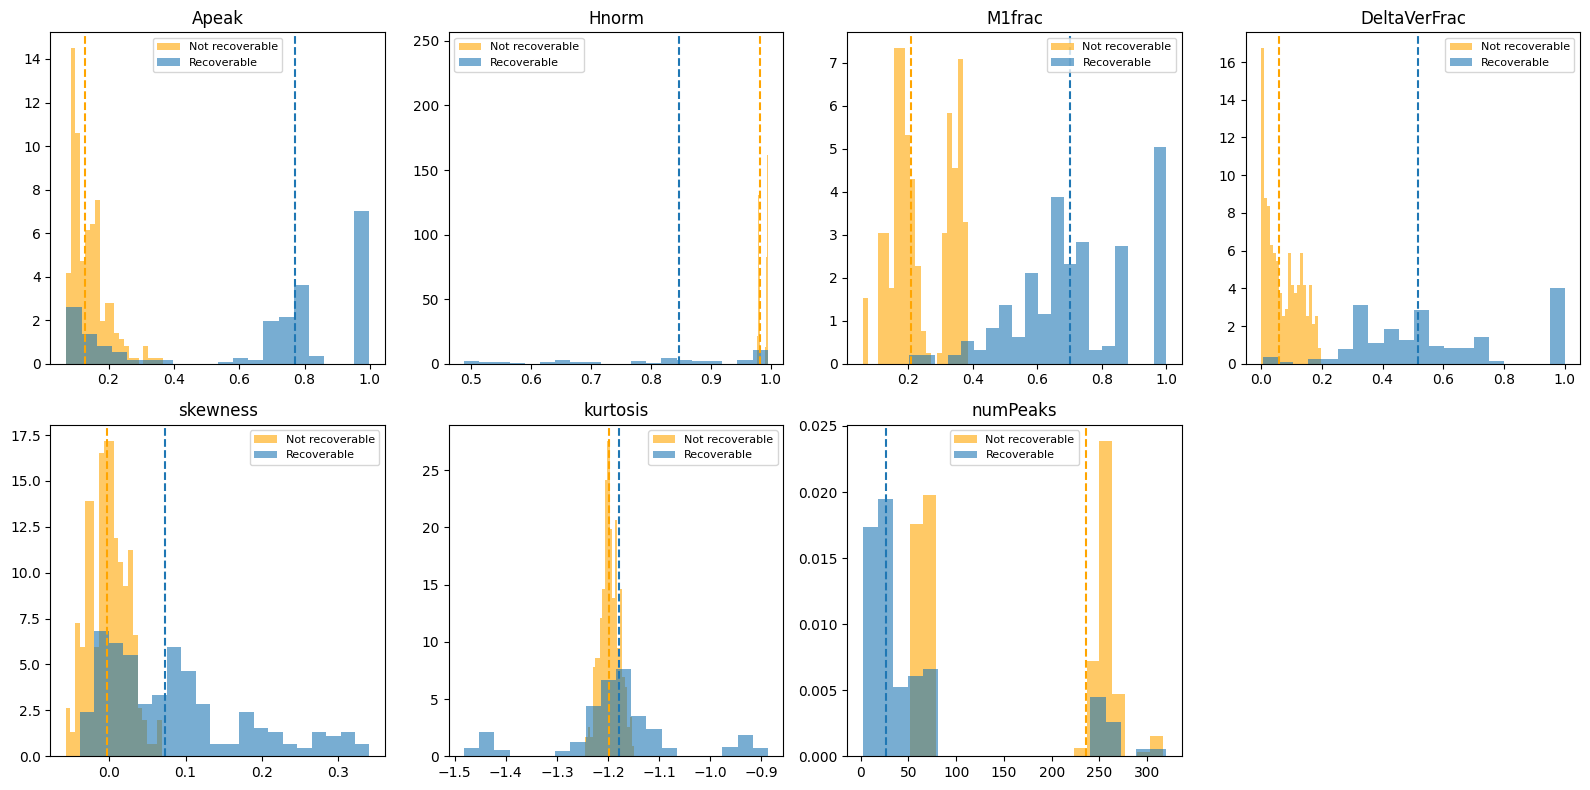

In [134]:
printMarginalFeatureDistributions (simulatordf, features, "figure3simulator")

In [140]:
printMultivariableTreeClassifier (simX, simy)

|--- DeltaVerFrac <= 0.20
|   |--- Apeak <= 0.37
|   |   |--- numPeaks <= 53.50
|   |   |   |--- DeltaVerFrac <= 0.04
|   |   |   |   |--- class: 0
|   |   |   |--- DeltaVerFrac >  0.04
|   |   |   |   |--- class: 1
|   |   |--- numPeaks >  53.50
|   |   |   |--- Apeak <= 0.33
|   |   |   |   |--- class: 0
|   |   |   |--- Apeak >  0.33
|   |   |   |   |--- class: 0
|   |--- Apeak >  0.37
|   |   |--- class: 1
|--- DeltaVerFrac >  0.20
|   |--- class: 1



In [142]:
printInterpretableDecisionTree (simulatordf, features, simX, simy)

0.9956597222222221 0.006105769741939953


In [143]:
printPermutationImportance(simulatordf, features, simX, simy)

DeltaVerFrac 0.30083333333333334
Apeak 0.054375000000000014
M1frac 0.005277777777777759
Hnorm 0.0036111111111110984
kurtosis 0.0029861111111111004
skewness 0.002499999999999991
numPeaks 0.0013194444444444397


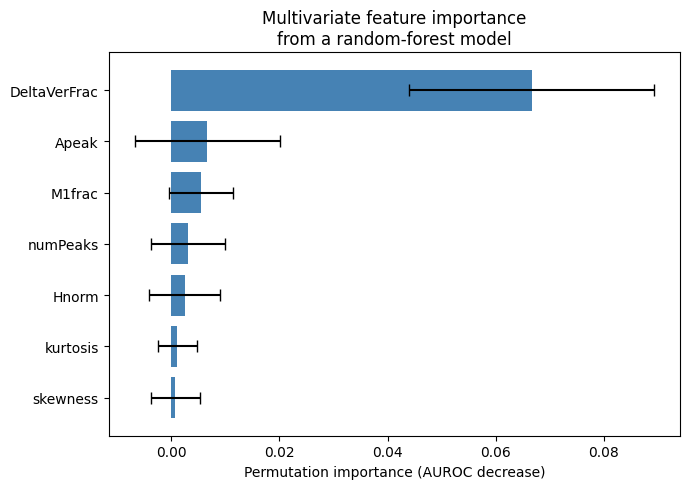

({'Apeak': np.float64(0.006662326388888915),
  'Hnorm': np.float64(0.002479745370370393),
  'M1frac': np.float64(0.0055673042709992095),
  'DeltaVerFrac': np.float64(0.06662614044583556),
  'skewness': np.float64(0.0007870370370370572),
  'kurtosis': np.float64(0.0011603009259259515),
  'numPeaks': np.float64(0.0031235532407407726)},
 {'Apeak': np.float64(0.013431864432380277),
  'Hnorm': np.float64(0.006522106275061948),
  'M1frac': np.float64(0.0059136083657791005),
  'DeltaVerFrac': np.float64(0.022640696092867073),
  'skewness': np.float64(0.0045404261518967705),
  'kurtosis': np.float64(0.0035245906197428722),
  'numPeaks': np.float64(0.006818993090710252)})

In [168]:
plotPermutationImportanceFigure(simX, simy, savename="figure5_simulator")

In [156]:
backendDataset = []

for N in [3, 7, 15, 31, 63]:

    with open (f"backendDatasetN{N}.json", "r") as f:
        backendDataset.extend (json.load (f))

backenddf = pd.DataFrame (backendDataset)

results = backenddf.apply(lambda row: calculateSkewKurtosisPeaks(row["counts"], row["Q"]), axis=1)
backenddf["skewness"] = results.apply(lambda x: x[0])
backenddf["kurtosis"] = results.apply(lambda x: x[1])
backenddf["numPeaks"] = results.apply(lambda x: x[2])

print (len (backendDataset))
print (len (backenddf))

384
384


In [157]:
numRecoverable = sum (exp["recoverable"] for exp in backendDataset)
numFailed = len (backendDataset) - numRecoverable

print (f"Recoverable: {numRecoverable}")
print (f"Not recoverable: {numFailed}")

Recoverable: 333
Not recoverable: 51


In [158]:
backX = backenddf[["Apeak", "Hnorm", "M1frac", "DeltaVerFrac", "skewness", "kurtosis", "numPeaks"]]
backy = backenddf["recoverable"].astype (int)

printSingleFeatureAUROC (backX, backy)

Apeak 0.9865748101042219
Hnorm 0.9349349349349348
M1frac 0.9175646234469763
DeltaVerFrac 0.9112642053818524
skewness 0.756580109521286
kurtosis 0.7924394983218512
numPeaks 0.9412059117941471


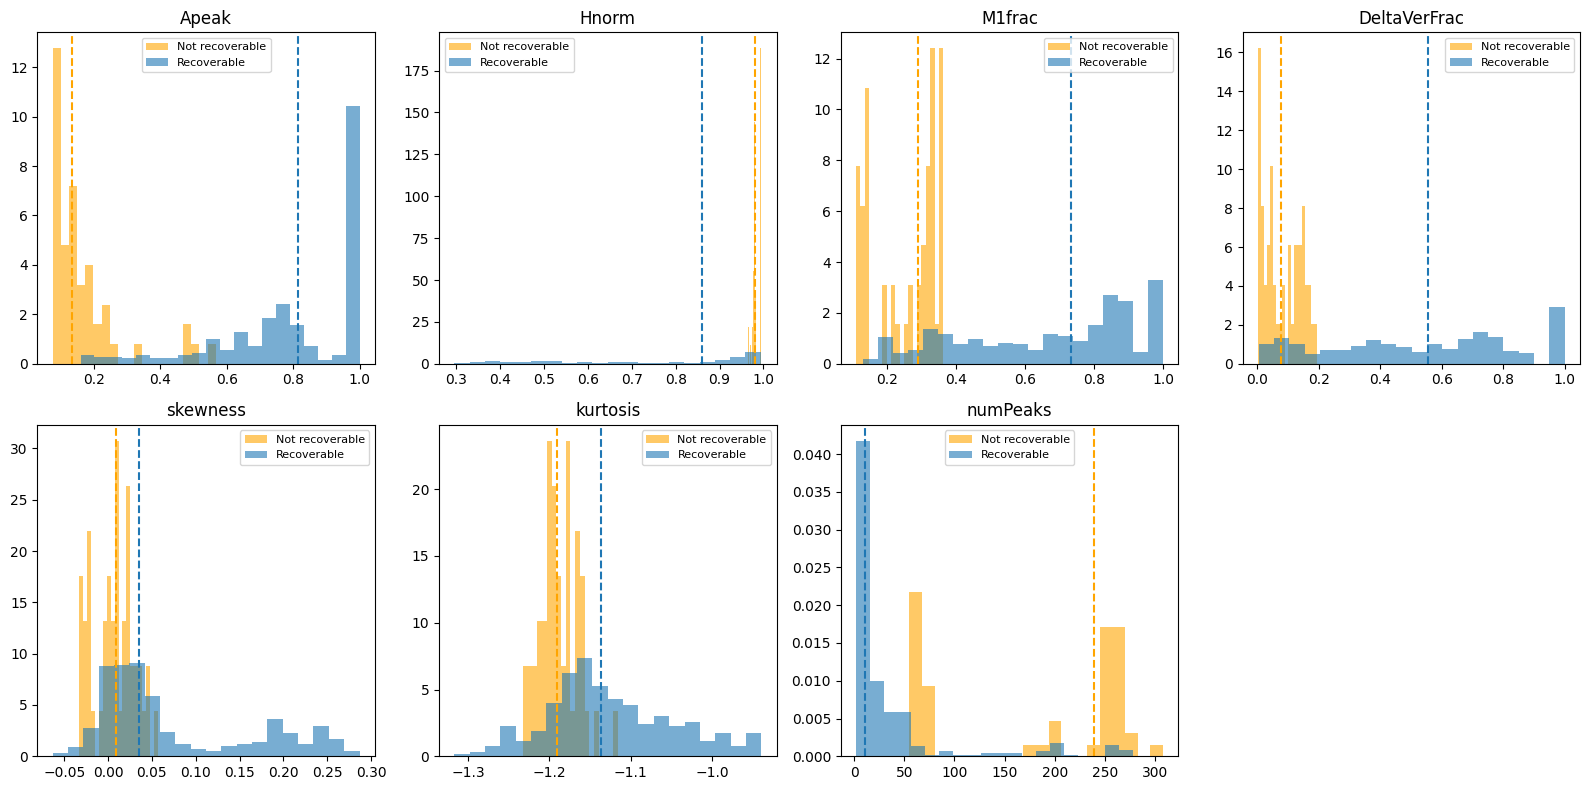

In [159]:
printMarginalFeatureDistributions (backenddf, features, "figure3backend")

In [160]:
printMultivariableTreeClassifier (backX, backy)

|--- Apeak <= 0.26
|   |--- Hnorm <= 0.98
|   |   |--- M1frac <= 0.28
|   |   |   |--- class: 0
|   |   |--- M1frac >  0.28
|   |   |   |--- class: 1
|   |--- Hnorm >  0.98
|   |   |--- Apeak <= 0.17
|   |   |   |--- class: 0
|   |   |--- Apeak >  0.17
|   |   |   |--- Apeak <= 0.18
|   |   |   |   |--- class: 1
|   |   |   |--- Apeak >  0.18
|   |   |   |   |--- class: 0
|--- Apeak >  0.26
|   |--- M1frac <= 0.14
|   |   |--- M1frac <= 0.13
|   |   |   |--- class: 1
|   |   |--- M1frac >  0.13
|   |   |   |--- class: 0
|   |--- M1frac >  0.14
|   |   |--- Hnorm <= 0.99
|   |   |   |--- DeltaVerFrac <= 0.01
|   |   |   |   |--- class: 1
|   |   |   |--- DeltaVerFrac >  0.01
|   |   |   |   |--- class: 1
|   |   |--- Hnorm >  0.99
|   |   |   |--- class: 0



In [161]:
printInterpretableDecisionTree (backenddf, features, backX, backy)

0.9916426133793841 0.006796892076142487


In [162]:
printPermutationImportance(backenddf, features, backX, backy)

Apeak 0.07083333333333332
numPeaks 0.04097222222222223
M1frac 0.01788194444444445
Hnorm 0.016406249999999997
DeltaVerFrac 0.007552083333333337
kurtosis 0.0003472222222222173
skewness 0.0


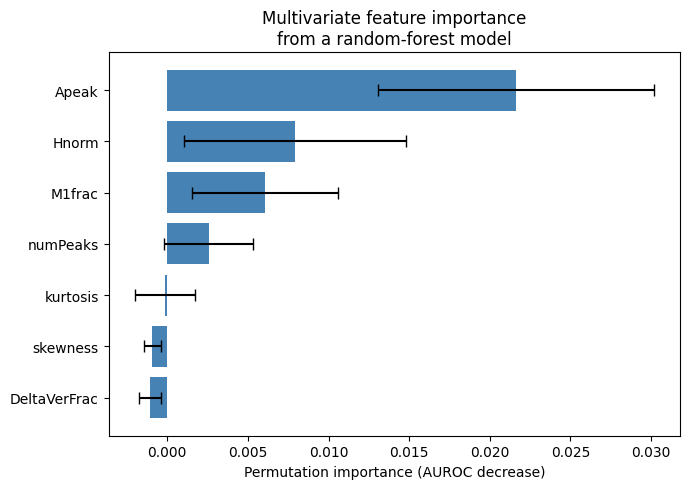

({'Apeak': np.float64(0.02161368775954935),
  'Hnorm': np.float64(0.007913887860970612),
  'M1frac': np.float64(0.006069274837931544),
  'DeltaVerFrac': np.float64(-0.0010888601071776176),
  'skewness': np.float64(-0.0009317119635979934),
  'kurtosis': np.float64(-0.00014370982552802366),
  'numPeaks': np.float64(0.002567054534490072)},
 {'Apeak': np.float64(0.008564359993965398),
  'Hnorm': np.float64(0.006895222758285523),
  'M1frac': np.float64(0.004539648763567082),
  'DeltaVerFrac': np.float64(0.0006757222340782574),
  'skewness': np.float64(0.0005179697364588766),
  'kurtosis': np.float64(0.0018773281573508862),
  'numPeaks': np.float64(0.0027676783068372427)})

In [169]:
plotPermutationImportanceFigure(backX, backy, savename="figure5_backend")

In [105]:
numRecoverable = sum (exp["recoverable"] for exp in simulatorDataset)
numFailed = len (simulatorDataset) - numRecoverable

print (f"Recoverable: {numRecoverable}")
print (f"Not recoverable: {numFailed}")

Recoverable: 359
Not recoverable: 241


In [104]:
numRecoverable = sum (exp["recoverable"] for exp in backendDataset)
numFailed = len (backendDataset) - numRecoverable

print (f"Recoverable: {numRecoverable}")
print (f"Not recoverable: {numFailed}")

Recoverable: 333
Not recoverable: 51


In [106]:
from collections import defaultdict

counts = defaultdict(lambda: {"recoverable": 0, "failed": 0})

for exp in simulatorDataset:
    n = exp["N"]
    if exp["recoverable"]:
        counts[n]["recoverable"] += 1
    else:
        counts[n]["failed"] += 1

for n in sorted(counts):
    r = counts[n]["recoverable"]
    f = counts[n]["failed"]
    print(f"N={n}: Recoverable: {r}  Not recoverable: {f}  (total={r+f})")

N=3: Recoverable: 60  Not recoverable: 0  (total=60)
N=7: Recoverable: 90  Not recoverable: 0  (total=90)
N=15: Recoverable: 55  Not recoverable: 35  (total=90)
N=31: Recoverable: 48  Not recoverable: 72  (total=120)
N=63: Recoverable: 58  Not recoverable: 62  (total=120)
N=127: Recoverable: 48  Not recoverable: 72  (total=120)


In [107]:
from collections import defaultdict

counts = defaultdict(lambda: {"recoverable": 0, "failed": 0})

for exp in backendDataset:
    n = exp["N"]
    if exp["recoverable"]:
        counts[n]["recoverable"] += 1
    else:
        counts[n]["failed"] += 1

for n in sorted(counts):
    r = counts[n]["recoverable"]
    f = counts[n]["failed"]
    print(f"N={n}: Recoverable: {r}  Not recoverable: {f}  (total={r+f})")

N=3: Recoverable: 48  Not recoverable: 0  (total=48)
N=7: Recoverable: 72  Not recoverable: 0  (total=72)
N=15: Recoverable: 72  Not recoverable: 0  (total=72)
N=31: Recoverable: 66  Not recoverable: 30  (total=96)
N=63: Recoverable: 75  Not recoverable: 21  (total=96)
